In [593]:
import numpy as np
import argparse
import pandas as pd
import os
from pathlib import Path
import matplotlib.pyplot as plt
import re
import math
import string
from scipy.stats import binom
from scipy.stats import kstest
from scipy.stats import geom
from scipy.stats import mannwhitneyu, wilcoxon, spearmanr
import re
import pickle
import Bio
from collections import Counter
import ast
from collections import defaultdict, Counter

# analysis of tomato hairy roots

In [249]:
tomato_df = pd.read_csv('/tamir2/shaicohen1/CRISPR_MAAGAD/For_Eran/Tomato-hairy-roots_eff (2).csv')

In [252]:
def reverse_complement(sequence: str) -> str:
    complement_map = {
        'A': 'T', 'T': 'A', 'G': 'C', 'C': 'G',
        'a': 't', 't': 'a', 'g': 'c', 'c': 'g',
        'N': 'N', 'n': 'n' }
    reversed_sequence = sequence[::-1]   
    complemented_sequence_list = []
    for base in reversed_sequence:
        complement_base = complement_map.get(base, base)
        complemented_sequence_list.append(complement_base)
    return "".join(complemented_sequence_list)

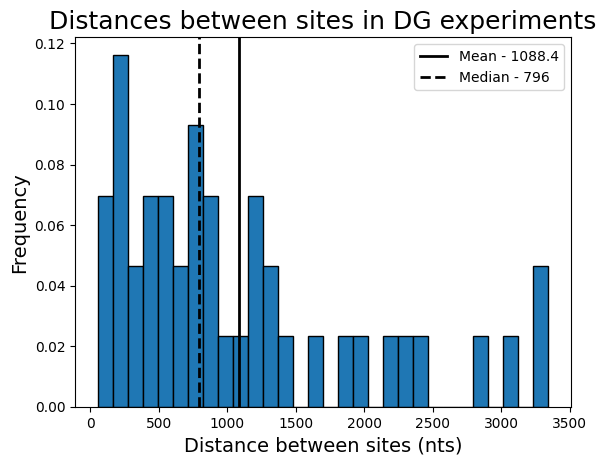

In [425]:
# get distances of sites in DG experiments
def find_grna_position(grna, amp):
    """Return (position, strand) if found, else (None, None)."""
    if grna in amp:
        return amp.index(grna), "+"
    rc = reverse_complement(grna)
    if rc in amp:
        return amp.index(rc), "-"
    return None, None

# group by SiteName without final _T1/_T2
tomato_df['BaseName'] = tomato_df['SiteName'].str.replace(r'-T[12]$', '', regex=True)
distances = []
for basename, group in tomato_df.groupby('BaseName'):
    if len(group) != 2:
        # print(group.SiteName)
        # print(f"Skipping {basename}: does not have exactly two rows")
        continue
    
    # extract the two rows (ensure consistent order)
    row1, row2 = group.iloc[0], group.iloc[1]
    
    g1 = row1['gRNA']
    amp1 = row1['AmpliconReference']
    pos1, strand1 = find_grna_position(g1, amp1)
    
    g2 = row2['gRNA']
    amp2 = row2['AmpliconReference']
    pos2, strand2 = find_grna_position(g2, amp2)

    if pos1 is None:
        # print(row1['SiteName'], "→ gRNA NOT FOUND")
        continue
    if pos2 is None:
        # print(row2['SiteName'], "→ gRNA NOT FOUND")
        continue

    # compute distance within the SAME amplicon (they are identical for T1/T2)
    distance = abs(pos1 - pos2)
    distances.append(distance)
    # print(f"{basename}:")
    # print(f"  {row1['SiteName']} gRNA @ {pos1} ({strand1})")
    # print(f"  {row2['SiteName']} gRNA @ {pos2} ({strand2})")
    # print(f"  → Distance: {distance} bp\n")
weights = np.ones(len(distances)) / len(distances)
plt.hist(distances, bins=30, edgecolor='black', weights=weights)  # density=True normalizes
mean = np.average(distances, weights=weights)
median = weighted_median(distances, weights)
plt.axvline(mean,color='black',linestyle="-", linewidth=2, label=f'Mean - {mean:.1f}')
plt.axvline(median,color='black', linestyle="--", linewidth=2, label=f'Median - {median:.0f}')
plt.xlabel('Distance between sites (nts)', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.legend()
plt.title('Distances between sites in DG experiments', fontsize=18)
plt.savefig('/tamir2/shaicohen1/CRISPR_MAAGAD/For_Eran/Distances between sites in double-guide experiments.svg')
plt.show()


In [404]:
tomato_df['BaseName'] = tomato_df['SiteName'].str.replace(r'-T[12]$', '', regex=True)
sg_amp_lengths = []
dg_amp_lengths = []
for basename, group in tomato_df.groupby('BaseName'):
    if len(group) == 2:
        row1, row2 = group.iloc[0], group.iloc[1]
        amp1 = row1['AmpliconReference']
        amp2 = row1['AmpliconReference']
        if amp1!=amp2:
            print('wtf dg amp diff')
        dg_amp_lengths.append(len(amp1))
    elif  len(group) == 1:
        row1 = group.iloc[0]
        amp1 = row1['AmpliconReference']
        sg_amp_lengths.append(len(amp1))
    else:
        print('wtf group size is not 1 or 2')
# print(len(sg_amp_lengths),len(dg_amp_lengths))


18 43


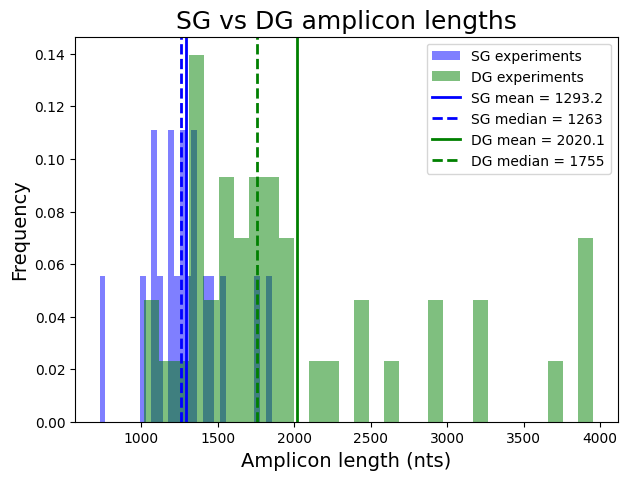

In [427]:
sg = np.array(sg_amp_lengths)
dg = np.array(dg_amp_lengths)

# Statistics
sg_mean, sg_median = np.mean(sg), np.median(sg)
dg_mean, dg_median = np.mean(dg), np.median(dg)

plt.figure(figsize=(7, 5))

bins = 30

# Weights so bars sum to 1 (probability)
sg_weights = np.ones_like(sg) / len(sg)
dg_weights = np.ones_like(dg) / len(dg)

plt.hist(
    sg, bins=bins, weights=sg_weights, alpha=0.5, color='blue',
    label="SG experiments"
)

plt.hist(
    dg, bins=bins, weights=dg_weights, alpha=0.5, color='green',
    label="DG experiments"
)

# Mean / median lines
plt.axvline(sg_mean, linestyle="-", linewidth=2, color='blue',
            label=f"SG mean = {sg_mean:.1f}")
plt.axvline(sg_median, linestyle="--", linewidth=2, color='blue',
            label=f"SG median = {sg_median:.0f}")

plt.axvline(dg_mean, linestyle="-", linewidth=2, color='green',
            label=f"DG mean = {dg_mean:.1f}")
plt.axvline(dg_median, linestyle="--", linewidth=2, color='green',
            label=f"DG median = {dg_median:.0f}")

plt.xlabel("Amplicon length (nts)", fontsize=14)
plt.ylabel("Frequency", fontsize=14)

plt.legend()
# plt.tight_layout()
plt.title('SG vs DG amplicon lengths', fontsize=18)
plt.savefig('/tamir2/shaicohen1/CRISPR_MAAGAD/For_Eran/SG vs DG amplicon lengths.svg')
plt.show()


# amplicon reads look

In [289]:
read = 'TACAATGACAGCTATGAGCAGTGAAAACCCATATCTCTTTGATTGGAATTAATGAAATAATCTTGTTAGGGTTTCCTTTTTATTGTTTTTAGCAACCCATTTTTTCTCATTTGTTTAAAAGAGTGGAGTTTAGAGGGGAAGTGCAATAAGGGTTCTTGTTTGTCCTATAACCAACCCCCTTTGCTTCTTCTTTAATTTTTGTGGTTTGGGTTTGTGAGTTTGTGTAATCACTAATCTGGGCTTAAATAAAAAAAAAAAAAAAATTTTTGTGGTGTATAATATGAAAGAGTGTGTTGGGAAAGTTTGGATCTGAAAGTGATTGAAAAGGGTGTTTTTGAGATTTAAAGTTTTGATTTTTGATAAGTGGGGGTTTAGTTTTTGATGAGTTTTGGAGTTTTATGAAGTATTAATGTGAGGGGAAAACGGTGGTGGGTTTCAAGATTGGTTGGGTGATACTTCATAACGAAGCCATTCCTACTGCTACTATGGCTCCGTCCACAGGCTTATCACATCCTCTTTATCTCATTCAATGTTTAACTTCTTCACCGTTTCTCTTGCTCTTGTAGGGCCCTCCTTTGATTTAAATTATACTCTTAATTAATTTTATTATTTGTTTGGTTGGGAATTGCGATTATATGTGTTTTTGGTAATTTTTTCAGGAAACCGAAAAATGGAAGGTCTGGTGATTTAAGCTTTGATGGAATGGAAGGAACGTCCAGAGCTGATAGTACAGAGCAGGTCTGGGACTGGGAGTGACAACTACTTTGATGGCGTTGGATCGGGTGATGAAATTGAACTCACATTTGTAGCTCATCCAATCGCAAAGAAGTACCATAGGCATACTCACATACCAAATCCAAGAGCTGGAGGCGTAGTGTTTATAACCAGCCCTTATGTTTTATGGGCTTTTGTCTTTTAAATTGTTTTTGTGAACTTTTTTTTTTAATCTGTCTGTCTTGTGCTGACAGTTTTCTTTAAGGAGAGTCACACCGGCTGAGAACAGCAAGCTGGAACTGGTAAGAAGGTTGACATTGGAAACAGGCAGGTTAAGTTCTGTTCCAGAAGAGGAGAACCCAAATGAAAGGTAAATGACAACACATTTACATTATTTTCTTGTGTTTCATTGTGTGAATGTATAAGTGAAAACCTACGTTTGTTTCAGACTCAGATGGAGCGGTGCATGAAAATTCAATGTTGAGCAGAGAATGATAAGCTTCGCATTGAGAACATAGCGATGAAGGAAGCGATGAGAAGCCAGCTGGTGCTCACATTGTGTGGTCAGGGCAATTCTTGGGGGGAGATACACTTTGAAGAGTCATCATTTGGCAGATTGAGAATGCCTCGGCTTGAGAGATTAATTACAGTAGGATCTGTGTTGTTGCAAACAAGTTTTTTCTGGTAGGCAGTGGAATCTGTCATGTCCAATGTCAAGCTGGAATGGCTAACTTCAGGTTTGGAACTTGCTGTGGGAAAAACGGCTTATGGTGCTATGAATTTCTGTTGACACTGCATTGCCAATGGTCTTAATTTGGCAATAATTTCTCAGTGCTCTACCATCTATTTCACCTAGGCCCGCCCCTGAGCATGGCCGTGTAGATGTATCTTTGATAGAACATGCTAATGGAGCTTGCTTGTTGCTTCCATGAATGAGCTGATTAAGCTGGCTGATATCGTGCTCCTCTGTGGCTTGGGAACTTTGATTGGACTGCGGAAGTATTGAACCTTGAGGATTATGCCAGGTCTTTTCCCTCCATGTATTGGCATTAAACCTGCCCATTTCACAGCAAAGCCAAACCAAGGCAACTGGTACTGTGAGGAATTACCAGTCTGACCTTGTGGAGACTTTCTGATGGACACAGTAGTTTCTTCATCCTGAAACCTGTAGTTGAGATTC'

In [296]:
amp_59 = 'TACAATGACAGCTATGAGCAGTGAAAACCCATATCTCTTTGATTGAATGAATGAAATAATCTTGTTAGGGTTTCCTTTTTATTGTTTTAGCCAACCCATTTTTTCTCATTTGTTTAAAAGAGTGGAGTTAGAGGGGAAGGTGCAATAAGGGTTCTTGGTTGTCTTATACCAACCCCCTTTGCTTCTTCTTTAATTTTTGTGGGTTTGGGTTGTTGAGTTTTGTGTTAATCACTAATCTTGGGCTAAATAAAAAAAAAAAAAATTTTGTGGGTGTATAAATATGAAAAGTGTGTTGGGAAAGTTGGGATCTTGAAAGTGATTGAAAAGGGTGTTTTTGAGATTAAAAGTTTTGATTTTTTGATAGAGTGGGGTTGAGTTTTGATGAGTTTTGGAGGTTTTATTGGAAGTAGTAGTGGAGGAAACGGTGGTGGGGTTTCAAGATTGGTGGGTGATACTTCATACGAAGCCATGCCTACTGCTACTATGGCTCAGTCACAGCTTATCACATCATCTTTATCTCATTCAATGTTTAACTCTTCACCGTTATCTCTTGCTCTTGTAGGCCTCCTTTATTTAAATTAGTACTACTTATTAATTTTATTTTATTTGTTGGTTGGGAATTGCGATTAATATGTGTTTTTGGGATAATTTTTCAGAAACCGAAAATGGAAGGTTCTGGTGATTTAAGCTTTGATGGAATGGGAAGGAACTCCAGAGATGATGAGTACGAGAGCAGGTCTGGGACTGGGAGTGACAACTTTGATGGCGTTGGATCGGGTGATGAAATTGAAACTCACATTGGTAGCTCATCCAAATCGGCAAAGAAGTACCATAGGCATACTCCATACCAAATCCAAGAGCTGGAGGCGTTAGTGTTTATAACCACCTTATGTTTATGCTTTTGTCTTTTAAATTGTTTGTGAAATTTTTTTAATCTGTCTGTCTTGTGCTGACAGTTTCTTTAAGGAGAGTCCACACCCGGATGAGAAAGCAAGGCTGGAACTTGGTAAGAGGTTGACATTGGAAAGCAGGCAGGTTAAGTTCTGGTTCCAGAACAGGAGAACCCAAATGAAGGTAAATGACAACACATTTAACATTATTTTCTTGTGTTTCATTGTGTGAATGTATAAGTGAAAACCTACGTTGTTTCAGACTCAGATGGAGCGTCATGAAAATTCAATGTTGAAGCAAGAGAATGATAAGCTTCGCATTGAGAACATAGCGATGAAGGAAGCGATGAGAAGCCCAGCTTGCCCACATTGTGGTGGTCAGGCAATTCTTGGGGAGATACACATTGAAGAGCATCATTTGAAGATTGAGAATGCTCGGCTGAGAGATGAATACAGTAGGATCTGTGTTGTTGCAAACAAGTTTCTGGGTAGGCAGGTGGAATCTGTCCATGGTCCAATGTCAGCTGGAATGGCTAATTCAGGTTTGGAACTTGCTGTGGGAAGAAACGGCTATGGTGCTATGAATTCTGTTGACACTGCATTGCCAATGGGTCTTAATTTTGGCAATAATTTCTCAAGTGCTCTACCAGCTATTTCACCTAGGCCCGCCCTGAGCATGGCCGGTGTAGATGTATCCTTTGATAGGAACATGCTAATGGAGCTTGCTTTTGCTTCCATGAATGAGCTGATTAAGCTGGCTGATATCGGTGCTCCTCTGTGGCTTGGAAACTTTGATGGAACTGCTGAAGTATTGAACCTTGAGGAGTATGCCAGGTCTTTTCCTCCATGTATTGGCATTAAACCTGCCCATTTCACAGCAGAAGCAACCAAGGCAACTGGTACTGTGATGATTAACAGTCTGACCTTGGTGGAGACTCTGATGGACACAGTAGGTTTCTTCATCCTGAAACCTGTAGTTGAGATTTC'
edited_read = 'TACAATGACAGCTATGACCGTGAAAACCCTATCTCTTTGATGAATGAATGAAATAATCTTGTTAGGGTTGTCCTTTTTTTTGTTTAAGCCACCCATTTTTTTCTCATTGTTTTAAAAGAGTGGATTTAGAGGGGAAGGTGCAATAAGGGTTCTTCTTGGTTGTCTTATACAAACCCCCTTTTGCTTCTCTTTATTTTTGTGGGTTTGGGGTTGTTGAGTTTTGTGTCATCCCTAATCTTTGGGCTAAATAAAAAAAAAAAAAAAAGTTTTTTTTTTGTGGTGTATAAAAATATGAAAAAGTGTGGTTGGGAAAGTTTTGGATCTTGAAAGGTGATTGAAAAGGGTGTTTTTGAGATTAAAAGTTTTGATTTTTGATAGAGTGGGGTGAGTTTGATGAGTTTTTGGAGGTGTTATTGGAAGTAGTAGTGAGGAAACGGGTGGTGGGTTTCAAGATTGGTGGGTGATACTTCATACGAAGGCCCATCCTACTGCTACTATGGCTCAGTCACAGCTTATCACATCATCTTTAATCTCATTTCATGTTTTAAACTCTTCACCGTTCTCTCTGCTCTTGTAAGCCTCCTTTATTTAAATTAGGATTAACTTTTAATTTTATTTAATTTGGGGTTGTTGGGAATTGCGATTAATATGTTTTTTTGGGGATAATTTTTCAGAACCGAAAATGGAAGGTTCTGGTGATTTAAGCTTTGATGGGAATGGGAAGGAACTCCAGAGTGAATGAGTACAAGCAGGTCTTGGGACGGAGTGCAACTTTTGATAGGCGTGGATCGGGTGATGAAATTGAAACTCACATTGGTAGCTCATCCGAAATCGCAAAGAAGTACGCATAGGCCTACGTCCCATACCAAATCCAAATAGCTGGAGGCGTTATGTTTAATAACCACCTTATGTTATAGCTTGTTTTGTCTTTAAATTGTTTGTGAATTTTTTTAATCTGTCCCTGTCTTGTGCTGACAGTTTTCTTTAAGGAGAGTCCACACCCGGATGAGAAGCAAGGCTTGAAACTTGGAACTTGGTAAGAGGTTGACATTGGAAAGCAGGCAGGTTAAGTTCTGTGTTCCAGAACAGGAGAACCAAATGAAGGTAAATGACAACACTGTAACATTATTTTTCTGTGTTTCATTGTGTGAATGTATACGTGAAAACCTACGTTGTTTCAGACTCAGAATGGAGCGTCATGAAACTTCAATGTTTGAATCAAAGAGAAATGAATAAGCTTCGCATTGAGAACATAGCGATGAAGGAAGCGATGAGAGCCTCAGCATTGCCCACATTGTGGGTGGTCAGGCAATTTCTTGGGAGATACACATTGAAGACATCATTTGAAGATTGAGAATGCTCGGCTGGAGATGAAGAACAGTAGGAATCTGTGTTGTTGCAAACAGTTTCTGGGTAGGCAGGTGGAAATCTGTTCCCAATGTTCCAATGTCAAGCTGGAATGGCTAATTCAGGTTTTGAACTTGCTGTGGGACTATGGTTGCTATGAATTCTGTTGACACGTGCCTTGCATGGGTCTTAATTTTGGCATAATTTCTAAGTGCTCTACCAGCTATTCACCTAGGCCCGCCTGAGCATGGCGGTGTAGATGTATCCTTTGATAGGAACATGCTAATTGGAGCTTGCTTTTGCTTCCATGATGAGCTGATTAAGCTGGCTGGATATCGTTCTCCTCTGTGGCTTGGAAACTTTTGATGGAACTGCTGAAGTAGTGACCTTGAGGAGTATCCAAGCGGGGGGGGGGGGGGGGGTTTTTTCCCCCCCCCCCCCTTTTTTTTTTTTTTTCCTCCATTAATTGGCATTAAACCTGCCCATTTCACAGCGAAGCAACCAAGGCAACTGGTACTAGTGATGAATTAACAGTCTGACCTTGTGGAGACTCTATGACACAGTAGGTTTCCTCATCCTGAACCTGTAGTTGAGATTTC'

In [297]:
from Bio import pairwise2
alignments = pairwise2.align.globalxx(edited_read, amp_59)
aln_read, aln_ref, score, start, end = alignments[1]

# alignment length = length of the aligned strings (including gaps)
alignment_length = len(aln_read)

# matches = score (because globalxx gives +1 per match)
matches = score

percent_identity = matches / alignment_length * 100

print("Matches:", matches)
print("Alignment length:", alignment_length)
print("Percent identity:", percent_identity, "%")

Matches: 1783.0
Alignment length: 2039
Percent identity: 87.44482589504659 %


# Extract short-read data + adding TMH data

In [547]:
def NEW_make_single_distribution(folder_name, files, min_lim, max_lim, keep_indels_only, remove_redundancy):
    sqa_used = set()
    total_frequencies = dict()
    num_dels_greater_than_ins = 0
    num_files=0
    for i,f in enumerate(files):
        # if i%100==0: print(i, f)
        match = re.search(r'(SQA_?#?\d+)', str(f))
        if match:
            sqa = match.group(1).replace("_", "").replace("#", "")
        else:
            sqa = str(f)

        if remove_redundancy and sqa in sqa_used:
            continue
        sqa_used.add(sqa)

        indel_freq = parse_allele_frequencies(f)
        num_del = 0
        num_ins = 0
        for k, v in indel_freq.items():
            if k<0:
                num_del+=v
            else:
                num_ins+=v
        num_files += 1
        if num_del>num_ins:
            num_dels_greater_than_ins+=1
    # Bucket large/small values
    # large_keys = [k for k in total_frequencies if k > max_lim]
    # small_keys = [k for k in total_frequencies if k < min_lim]

    # if min_lim not in total_frequencies:
    #     total_frequencies[min_lim] = 0
    # for k in small_keys:
    #     total_frequencies[min_lim] += total_frequencies[k]

    # if max_lim not in total_frequencies:
    #     total_frequencies[max_lim] = 0
    # for k in large_keys:
    #     total_frequencies[max_lim] += total_frequencies[k]

    # for k in small_keys + large_keys:
    #     del total_frequencies[k]

    # if keep_indels_only and 0 in total_frequencies:
    #     del total_frequencies[0]
    
    # # # Normalize
    # sum_count = sum(total_frequencies.values())
    # for k in list(total_frequencies.keys()):
    #     total_frequencies[k] /= sum_count

    return num_dels_greater_than_ins,num_files  

In [23]:
def sanitize_filename(name):
    """Remove characters that are unsafe for file names."""
    safe = "-_.() %s%s" % (string.ascii_letters, string.digits)
    return "".join(c for c in name if c in safe).replace(" ", "_")


def parse_allele_frequencies(allele_frequencies_file):
    data = pd.read_csv(allele_frequencies_file, sep='\t')
    indel_length_frequencies = dict()
    for i in data.index:
        indel_length = data.at[i, 'n_inserted'] - data.at[i, 'n_deleted']
        freq = data.at[i, '%Reads']
        indel_length_frequencies[indel_length] = indel_length_frequencies.get(indel_length, 0) + freq
    return indel_length_frequencies


def make_single_distribution(folder_name, files, min_lim, max_lim, keep_indels_only, remove_redundancy):
    sqa_used = set()
    total_frequencies = dict()

    for i,f in enumerate(files):
        # if i%100==0: print(i, f)
        match = re.search(r'(SQA_?#?\d+)', str(f))
        if match:
            sqa = match.group(1).replace("_", "").replace("#", "")
        else:
            sqa = str(f)

        if remove_redundancy and sqa in sqa_used:
            continue
        sqa_used.add(sqa)

        indel_freq = parse_allele_frequencies(f)
        for k, v in indel_freq.items():
            total_frequencies[k] = total_frequencies.get(k, 0) + v

    # Bucket large/small values
    # large_keys = [k for k in total_frequencies if k > max_lim]
    # small_keys = [k for k in total_frequencies if k < min_lim]

    # if min_lim not in total_frequencies:
    #     total_frequencies[min_lim] = 0
    # for k in small_keys:
    #     total_frequencies[min_lim] += total_frequencies[k]

    # if max_lim not in total_frequencies:
    #     total_frequencies[max_lim] = 0
    # for k in large_keys:
    #     total_frequencies[max_lim] += total_frequencies[k]

    # for k in small_keys + large_keys:
    #     del total_frequencies[k]

    if keep_indels_only and 0 in total_frequencies:
        del total_frequencies[0]
    
    # # Normalize
    sum_count = sum(total_frequencies.values())
    for k in list(total_frequencies.keys()):
        total_frequencies[k] /= sum_count

    return total_frequencies

def best_rectangle(n):
    """Find the most rectangular rows × cols for n plots."""
    cols = math.ceil(n ** 0.5)
    rows = math.ceil(n / cols)
    return rows, cols

def is_prime(n):
    if n < 2:
        return False
    for i in range(2, int(n**0.5) + 1):
        if n % i == 0:
            return False
    return True

def trim_edges(total_frequencies, max_lim, min_lim):
    # Bucket large/small values
    large_keys = [k for k in total_frequencies if k > max_lim]
    small_keys = [k for k in total_frequencies if k < min_lim]

    if min_lim not in total_frequencies:
        total_frequencies[min_lim] = 0
    for k in small_keys:
        total_frequencies[min_lim] += total_frequencies[k]

    if max_lim not in total_frequencies:
        total_frequencies[max_lim] = 0
    for k in large_keys:
        total_frequencies[max_lim] += total_frequencies[k]

    for k in small_keys + large_keys:
        del total_frequencies[k]

    return total_frequencies



In [646]:
#main
# fig "all" a-i
# super_folder = Path('/tamir2/shaicohen1/CRISPR_MAAGAD/For_Eran')
# folders_in_superfolder = [f for f in super_folder.iterdir() if f.is_dir()
# and 'ipynb' not in str(f) and 'SORTED' not in str(f) and 'replicates' not in str(f) and 'mistake' not in str(f)]

#Tomato leaf 3 companies
super_folder = Path('/tamir2/shaicohen1/CRISPR_MAAGAD/For_Eran/Tomato protoplasts SORTED')
folders_in_superfolder = [f for f in super_folder.iterdir() if f.is_dir()
and 'ipynb' not in str(f)]

# # human replicates
# super_folder = Path('/tamir2/shaicohen1/CRISPR_MAAGAD/For_Eran/T_replicates')
# folders_in_superfolder = [f for f in super_folder.iterdir() if f.is_dir()]

all_results = {}
for folder in folders_in_superfolder:
    cell_name = str(folder).split('/')[-1]
    print(cell_name)
    freq_tables = list(folder.rglob("Alleles_frequency_table_around*"))
    if len(freq_tables) == 0:
        print(f"[WARNING] No CRISPResso allele tables found in: {folder}")
        continue
    freqs = make_single_distribution(
        folder.name,
        freq_tables,
        -50,#args.min,
        20,#args.max,
        True, #args.indels,
        True,#args.nr
    )
    if cell_name == 'Tomato protoplasts':
        cell_name = 'Tomato leaf'
    all_results[cell_name] = freqs



# plot_all_cells(curr_cell_results, args.min, args.max, args.title)
print('done')


Rahan
Hazera
Betterseeds
done


In [648]:
#main
# fig "all" a-i
# super_folder = Path('/tamir2/shaicohen1/CRISPR_MAAGAD/For_Eran')
# folders_in_superfolder = [f for f in super_folder.iterdir() if f.is_dir()
# and 'ipynb' not in str(f) and 'SORTED' not in str(f) and 'replicates' not in str(f) and 'mistake' not in str(f)]

# #Tomato leaf 3 companies
# super_folder = Path('/tamir2/shaicohen1/CRISPR_MAAGAD/For_Eran/Tomato protoplasts SORTED')
# folders_in_superfolder = [f for f in super_folder.iterdir() if f.is_dir()
# and 'ipynb' not in str(f)]

# human replicates
super_folder = Path('/tamir2/shaicohen1/CRISPR_MAAGAD/For_Eran/T_replicates')
folders_in_superfolder = [f for f in super_folder.iterdir() if f.is_dir()]

all_results = {}
for folder in folders_in_superfolder:
    cell_name = str(folder).split('/')[-1]
    print(cell_name)
    freq_tables = list(folder.rglob("Alleles_frequency_table_around*"))
    if len(freq_tables) == 0:
        print(f"[WARNING] No CRISPResso allele tables found in: {folder}")
        continue
    freqs = make_single_distribution(
        folder.name,
        freq_tables,
        -50,#args.min,
        20,#args.max,
        True, #args.indels,
        True,#args.nr
    )
    if cell_name == 'Tomato protoplasts':
        cell_name = 'Tomato leaf'
    all_results[cell_name] = freqs



# plot_all_cells(curr_cell_results, args.min, args.max, args.title)
print('done')


CRISPResso_on_SQA0007667_g133_S4_R1_SQA0007667_g133_S4_R2
CRISPResso_on_SQA0011442_g221_S32_R1_SQA0011442_g221_S32_R2
CRISPResso_on_SQA0007667_g133_S27_R1_SQA0007667_g133_S27_R2
CRISPResso_on_SQA0011442_g221_S43_R1_SQA0011442_g221_S43_R2
done


In [259]:
def load_treatment_csv(folder_path, no_subs=True):
    """
    Attempts to load treatment_aligned_reads.csv from a folder.
    If not found, tries treatment_aligned_reads.csv.gz and extracts it in memory.
    Returns a dataframe filtered to is_edited == True containing ONLY the requested columns.
    """
    # print(folder_path)
    amp_name = folder_path.split('\\')[-1]
    if 'single_guides' in folder_path:
        parts = folder_path.split('\\')
        origin_name = parts[-3]
    elif 'double_guides' in folder_path:
        parts = folder_path.split('\\')
        origin_name = parts[-3]
    print(origin_name, amp_name)
    # Requested columns from user
    cols_wanted = [
        "frequency",
        "alignment_score",
        "alignment_cut_site",
        "deleted_bases_length",
        "deletion_start_position",
        "deletion_end_position",
        "deleted_bases",
        "inserted_bases_length",
        "insertion_position",
        "inserted_bases",
        "substitution_count",
        "substitution_position",
        "substitution_bases",
        "is_edited"
    ]

    csv_path = os.path.join(folder_path, "treatment_aligned_reads.csv")
    gz_path = csv_path + ".gz"

    df = None
    # print(gz_path)
    # Case 1: CSV exists
    if os.path.isfile(csv_path):
        df = pd.read_csv(csv_path, usecols=lambda c: c in cols_wanted)
    
    # Case 2: GZ exists — extract directly from gzip with no temp file
    elif os.path.isfile(gz_path):
        with gzip.open(gz_path, "rt") as f:
            df = pd.read_csv(f, usecols=lambda c: c in cols_wanted)

    else:
        print(f"No treatment_aligned_reads.csv or .csv.gz found in: {folder_path}")
        return pd.DataFrame()

    # Filter to edited rows
    if "is_edited" not in df.columns:
        raise ValueError("Column 'is_edited' missing from file!")

    df['frequency'] = df['frequency']/df['frequency'].sum()
    df = df[df["is_edited"] == True].reset_index(drop=True)
    df['origin'] = origin_name
    df['amp_name'] = amp_name
    if no_subs:
        df = df[df['substitution_position'].isna()]
    df = df[~df["deleted_bases_length"].astype(str).str.contains(",")]
    df = df[~df["insertion_position"].astype(str).str.contains(",")]
    DEL_hist = df.groupby("deleted_bases_length")["frequency"].sum().sort_index()
    INS_hist = df.groupby("inserted_bases_length")["frequency"].sum().sort_index()
    INS_nts = df.groupby("inserted_bases")["frequency"].sum().sort_index()
    
    # DEL_hist = extract_from_commas(df,'deleted_bases_length')
    # INS_hist = extract_from_commas(df,'inserted_bases_length')
    # INS_nts = extract_from_commas(df,'inserted_bases')
    INS_nts = INS_nts.reindex(['A','C','G','T'], fill_value=0)
    res_df = pd.DataFrame({'amp':[amp_name],
                           'origin':[origin_name],
                           'path':[folder_path],
                           'no_subs':[1 if no_subs else 0]})
    res_df.loc[0,'DEL_len'] = str({x:y for x,y in zip(DEL_hist.index,DEL_hist.to_list())})
    res_df.loc[0,'INS_len'] = str({x:y for x,y in zip(INS_hist.index,INS_hist.to_list())})
    res_df.loc[0,'INS_nts'] = str({x:y for x,y in zip(INS_nts.index,INS_nts.to_list())})
    return res_df

In [260]:
# root_folder=r"C:\Users\shaic\Downloads\x\y"
# results = {}

# for dirpath, dirnames, filenames in os.walk(root_folder):
#     # Check folders starting with 'amp'
#     for d in dirnames:
#         if d.lower().startswith("amp"):
#             full_path = os.path.join(dirpath, d)
#             res_df = load_treatment_csv(full_path)
#             if len(results)>0:
#                 results = pd.concat([results,res_df])
#             else:
#                 results = res_df
# results.index=range(len(results))
# # results.to_csv(r"C:\Users\shaic\Downloads\x\thr_no_subs_no_splits_11_12_25.csv")
# print('done')

In [515]:
def sum_dict_column(df, colnames, filtering=True):
    total = Counter()

    for i in df.index:
        for colname in colnames:
            s = df.loc[i,colname]
            d = ast.literal_eval(s)      # convert string → dict safely
            if 'INS' in colname:
                d = {int(x):d[x] for x in d.keys()}
            else:
                d = {-int(x):d[x] for x in d.keys()}
            if filtering and colname=='DEL_len' and 'SG_' not in df.loc[i,'origin']: 
                # 99% of the dels in single-guide amplicon were less than 500, with the max amplicon length being 1800 (median 1200)
                # including the DG (that are most experiments) gRNAs experiment 90% were <~500 and 99% were <~900 (amplicon mean was 2000... max 4000, median 1700)
                # regarding our claims about short\long deletions - this does not change the conclusions
                # in fact the data might be biased towards longer deletions in cases where the two sites
                # are too close and the two deletions are overlapping
    
                # regarding INS - 99% was under 13 in single guide INS, and 99% was under 39 including DG...
                d = {x:d[x] for x in d.keys() if x>-500}
            total.update(d)              # add values
    total = dict(total)
    # total = {x: total[x]/sum(total.values()) for x in total.keys()}
    return dict(total)

In [345]:
a_df = pd.read_csv("/tamir2/shaicohen1/CRISPR_MAAGAD/For_Eran/Tomato hairy roots results/thr_no_subs_no_splits_11_12_25.csv")
raw_tmh = sum_dict_column(a_df,['DEL_len','INS_len'],False)
raw_sg_tmh = sum_dict_column(a_df[a_df.origin.str.contains('SG_')],['DEL_len','INS_len'],False)

In [346]:
raw_tmh_results = {}
raw_tmh_results['Single-guide experiments (n=18)'] = raw_sg_tmh.copy()
raw_tmh_results['Unfiltered experiment (n=104)'] = raw_tmh.copy()

In [288]:
SG_tmh

{-1: 0.06449259177456942,
 -10: 0.016785510025136955,
 -107: 0.0007849840609498784,
 -111: 0.00844050037227682,
 -112: 0.003691561657731511,
 -113: 0.0010095812254336646,
 -114: 0.0006131527588154655,
 -121: 0.0012854574587698436,
 -127: 9.940265642637609e-05,
 -13: 0.002901034935354196,
 -163: 0.0027982866375858106,
 -184: 0.0001362172111309275,
 -189: 0.00966072029640267,
 -198: 0.00078344116878362,
 -2: 0.04174252042996848,
 -200: 0.0031172085309633057,
 -206: 0.0003059556729193312,
 -207: 0.00010293452844409012,
 -208: 0.0004358986155664554,
 -209: 0.0001505252575048465,
 -23: 0.009032531828674443,
 -239: 0.0005165934256338774,
 -244: 0.00045465227626899693,
 -245: 0.00015025197914485974,
 -26: 0.00042831325279544977,
 -28: 0.0008988961623677066,
 -287: 8.172431615104482e-06,
 -3: 0.050402884875016006,
 -30: 0.0030945827069359076,
 -31: 0.0046688144570580445,
 -317: 3.506554054032608e-05,
 -32: 0.009819963499129539,
 -322: 1.810420614734951e-05,
 -33: 0.002707270343511801,
 -335: 3

In [282]:
spearmanr(keys_sorted,values_sorted)

SignificanceResult(statistic=np.float64(0.8400656591429092), pvalue=np.float64(0.0))

In [533]:
ALL_tmh = '/tamir2/shaicohen1/CRISPR_MAAGAD/For_Eran/Tomato hairy roots results/ALL_tmh_DEL_INS_no_splits.pkl'
SG_tmh = '/tamir2/shaicohen1/CRISPR_MAAGAD/For_Eran/Tomato hairy roots results/SG_tmh_DEL_INS_no_splits.pkl'
with open(ALL_tmh, 'rb') as file:
    ALL_tmh = pickle.load(file)
with open(SG_tmh, 'rb') as file:
    SG_tmh = pickle.load(file)  
all_results['Tomato hairy roots'] = ALL_tmh
# add Human
human = {}
for human_cell in ['PLX','K562','U937','T']:
    for k, v in all_results[human_cell].items():
        human[k] = human.get(k, 0) + v
sum_count =  sum(human.values())
for k in list(human.keys()):
    human[k] /=sum_count
all_results['Human'] = human.copy()
#make pseusdo-short tomato hairy roots
# take deletions up to 18 since in tomato leaf the biggest increase in number of deletion lengths was between 96 to 97% 
# (18 to 36, up till then it was 0-2 for each increase in percentage)
tmh_pseudo_short_reads = sum_dict_column(a_df,['DEL_len','INS_len'],True) # NO NORMALIZATION INSIDE!
tmh_pseudo_short_reads = {x:tmh_pseudo_short_reads[x] for x in range(-18,100) if x in tmh_pseudo_short_reads.keys()}
all_results['Tomato hairy roots (pseudo-short reads)'] = {x: tmh_pseudo_short_reads[x]/sum(tmh_pseudo_short_reads.values()) for x in tmh_pseudo_short_reads.keys()}
# {x:all_results['Tomato hairy roots'][x] for x in range(-18,100)
#  if x in all_results['Tomato hairy roots'].keys()}
# sum_count =  sum(all_results['Tomato hairy roots (pseudo-short reads)'].values())
# for k in list(all_results['Tomato hairy roots (pseudo-short reads)'].keys()):
#     all_results['Tomato hairy roots (pseudo-short reads)'][k] /=sum_count
#add tomato = leaf + hairy roots (pseudo)
tomato = {}
for k, v in  all_results['Tomato hairy roots (pseudo-short reads)'].items():
    tomato[k] = tomato.get(k, 0) + v
for k, v in all_results['Tomato leaf'].items():
    # if k in range(-num_lens,20):
    tomato[k] = tomato.get(k, 0) + v    
sum_count = sum(tomato.values())
print(sum_count)
for k in list(tomato.keys()):
    tomato[k] /= sum_count
# all_results['Tomato (pseudo-short reads)'] = tomato.copy()

2.0000000000000018


In [522]:
# Open the file in write-binary mode ('wb') and dump the object
with open('/tamir2/shaicohen1/CRISPR_MAAGAD/For_Eran/all_results.pkl', 'wb') as file:
    pickle.dump(all_results, file)

In [239]:
with open('/tamir2/shaicohen1/CRISPR_MAAGAD/For_Eran/all_results.pkl', 'rb') as file:
    # Use pickle.load() to deserialize the data from the file object
    all_results = pickle.load(file)

In [514]:
for x in all_results.keys():
    if x!='Tomato leaf':
        continue
    threshold = 0.97
    
    # 1. Take only negative keys and sort them from lowest (most negative) to highest
    neg_keys_sorted = sorted([k for k in all_results[x] if k < 0])
    all_neg_sum = sum([all_results[x][k] for k in neg_keys_sorted])
    neg_keys_sorted.reverse()
    # 2. Accumulate values
    running_sum = 0
    for k in neg_keys_sorted:
        running_sum += all_results[x][k]/all_neg_sum
        if running_sum >= threshold:
            print(x, k)
            break

Tomato leaf -35


# Plot graphs

In [504]:
def weighted_median(values, weights):
    """
    Return the weighted median of `values` with corresponding `weights`.
    `values` and `weights` can be numpy arrays or lists. Handles edge cases:
      - If total weight is 0 -> returns np.nan
      - If a single value -> returns that value
    """
    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)

    if values.size == 0:
        return np.nan

    if values.size == 1:
        return float(values[0])

    # remove entries with zero weight
    mask = weights > 0
    if not np.any(mask):
        return np.nan
    v = values[mask]
    w = weights[mask]

    # sort by value
    sorter = np.argsort(v)
    v = v[sorter]
    w = w[sorter]

    # cumulative weights
    cumw = np.cumsum(w)
    total = cumw[-1]
    half = total / 2.0

    # first index where cumulative >= half
    idx = np.searchsorted(cumw, half, side="left")
    return float(v[idx])

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import math
import re


def plot_all_cells_new_hist(all_results, min_lim, max_lim, main_title, folder_save, cell_names='all'):
    """
    Plot a grid of histograms (forced 4 columns). Deletions (neg lengths) are red,
    insertions (pos lengths) are blue. For each, draw mean (solid) and median (dashed).
    One bin per integer length between min_lim and max_lim inclusive.
    """
    # -----------------------
    # Determine which cells
    # -----------------------
    cell_names = all_results.keys()
    if cell_names == 'all':
        cell_names = [
            'Human', 'Fly', 'Prawn', 'Tomato', 'K562', 'T', 'U937', 'PLX',
            'Tomato leaf', 'Tomato hairy roots (pseudo-short reads)',
            'Tomato hairy roots'
        ]
    else:
        cell_names = sorted(all_results.keys())

    print(cell_names)
    n_cells = len(cell_names)

    # -----------------------
    # FORCE 4 columns
    # -----------------------
    cols = 4
    rows = math.ceil(n_cells / cols)

    plt.figure(figsize=(6 * cols, 4 * rows))
    plt.suptitle(main_title, fontsize=22, fontweight="bold")

    ABC = "ABCDEFGHIJKLMNOPQESTUVWXYZ"

    # one bin per integer: edges at x-0.5 ... x+0.5
    bins = np.arange(min_lim - 0.5, max_lim + 1.5, 1)

    # -----------------------
    # Create each subplot
    # -----------------------
    for i, cell in enumerate(cell_names, 1):
        print(cell)
        # get & crop freqs
        freqs = dict(sorted(all_results[cell]['freqs'].items()))
        freqs = trim_edges(freqs, max_lim, min_lim)

        # -----------------------
        # SQA renaming
        # -----------------------
        if 'SQA' in cell:
            regex = re.compile(r'^CRISPResso_on_SQA(\d+).*?_S(\d+)_R1')
            m = regex.search(cell)
            if m:
                cell = f"SQA{m.group(1)} S{m.group(2)}"

        # -----------------------
        # Convert to arrays
        # -----------------------
        lengths = np.array(list(freqs.keys()), dtype=float)
        weights = np.array(list(freqs.values()), dtype=float)

        # masks
        neg_mask = lengths < 0   # deletions
        pos_mask = lengths > 0   # insertions

        ax = plt.subplot(rows, cols, i)

        # -----------------------
        # HISTOGRAM: DELETIONS (red)
        # -----------------------
        if np.any(neg_mask):
            ax.hist(
                lengths[neg_mask],
                bins=bins,
                weights=weights[neg_mask],
                color="red",
                alpha=0.6,
                label="Deletion"
            )

            # mean & median
            neg_mean = np.average(lengths[neg_mask], weights=weights[neg_mask])
            neg_median = weighted_median(lengths[neg_mask], weights[weights > 0][neg_mask])
            ax.axvline(neg_mean, color="red", linestyle="-", linewidth=2)
            ax.axvline(neg_median, color="red", linestyle="--", linewidth=2)

        # -----------------------
        # HISTOGRAM: INSERTIONS (blue)
        # -----------------------
        if np.any(pos_mask):
            ax.hist(
                lengths[pos_mask],
                bins=bins,
                weights=weights[pos_mask],
                color="blue",
                alpha=0.6,
                label="Insertion"
            )

            # mean & median
            pos_mean = np.average(lengths[pos_mask], weights=weights[pos_mask])
            pos_median = weighted_median(lengths[pos_mask], weights[weights > 0][pos_mask])
            ax.axvline(pos_mean, color="blue", linestyle="-", linewidth=2)
            ax.axvline(pos_median, color="blue", linestyle="--", linewidth=2)

        # labels / limits / legend
        ax.set_xlim(min_lim - 1, max_lim + 1)
        ax.set_title(rf"$\mathbf{{{ABC[i-1]}}}$. {cell}", fontsize=18)
        ax.set_xlabel("Indel length", fontsize=17)
        ax.set_ylabel("Frequency", fontsize=17)
        ax.tick_params(labelsize=16)
        ax.legend(fontsize=10)

    plt.tight_layout(rect=[0, 0, 1, 0.95])

    safe_name = sanitize_filename(main_title)
    outfile = f"{folder_save}/{safe_name}.svg"
    # plt.savefig(outfile)
    print(f"Saved: {outfile}")


In [226]:
def plot_all_cells(all_results, min_lim, max_lim, main_title, folder_save):
    cell_names = sorted(all_results.keys())
    n_cells = len(cell_names)
    if n_cells==1:
        rows = 1
        cols = 1
    elif n_cells == 3:
        rows = 1
        cols = 3
    elif is_prime(n_cells):
        # Create best rectangle for n_cells - 1
        base_rows, base_cols = best_rectangle(n_cells - 1)
    
        # Add one more row for the final subplot
        rows = base_rows + 1
        cols = base_cols
    else:
        # Standard rectangular layout
        rows, cols = best_rectangle(n_cells)
    
    plt.figure(figsize=(6 * cols, 4 * rows))
    plt.suptitle(main_title, fontsize=20, fontweight="bold")
    print(cell_names)
    if cell_names == ['Fly', 'Human', 'K562', 'PLX', 'Prawn', 'T', 'Tomato protoplasts', 'U937']:
        cell_names = ['Human', 'K562', 'T', 'U937','PLX', 'Fly','Prawn', 'Tomato protoplasts' ]
    ABC = 'ABCDEFGHIJKLMNOPQESTUVWXYZ'
    for i, cell in enumerate(cell_names, 1):
        freqs = dict(sorted(all_results[cell]['freqs'].items()))
        freqs = trim_edges(freqs, max_lim, min_lim)
        if 'SQA' in cell: 
            regex = re.compile(r'^CRISPResso_on_SQA(\d+).*?_S(\d+)_R1')
            match = regex.search(cell)
            if match:
                sqa_id = match.group(1) # Capture Group 1 (X)
                s_id = match.group(2)   # Capture Group 2 (Y)
            cell = f"SQA{sqa_id} S{s_id}"
        plt.subplot(rows, cols, i)
        plt.bar(list(freqs.keys()), list(freqs.values()))
        plt.xlim(min_lim - 1, max_lim + 1)
        # plt.title(f"{ABC[i]}. {cell} cell", fontsize=14)
        plt.title(rf"$\mathbf{{{ABC[i-1]}}}$. {cell}", fontsize=18)
        plt.xlabel("Indel length", fontsize=18)
        plt.ylabel("Frequency", fontsize=18)
        plt.tick_params(labelsize=18)
    
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    
    # SVG output using sanitized title
    safe_name = sanitize_filename(main_title)
    outfile = f"{folder_save}/{safe_name}.svg"
    plt.savefig(outfile)
    print(f"Saved: {outfile}")



In [644]:
def plot_all_cells_new(cell_names,all_results, min_lim, max_lim, main_title, folder_save,num_cols=4,diff_spacing=False):
    if cell_names =='all':
        cell_names = ['Human', 'Fly', 'Prawn',# 'Tomato (pseudo-short reads)',
                      'K562', 'T', 'U937', 'PLX', 
                      'Tomato leaf', 'Tomato hairy roots', 'Tomato hairy roots (Zoom in (-50,20))']
    else:
        cell_names = sorted(all_results.keys())
    print(cell_names)

    n_cells = len(cell_names)

    
    # ---- FORCE 4 COLUMNS ----
    cols = num_cols
    if cols==4:
        rows = math.ceil(n_cells / 4)
    elif cols==3:
        rows=4
    elif cols==2:
        rows=2

    plt.figure(figsize=(6 * cols, 4 * rows))
    plt.suptitle(main_title, fontsize=30, fontweight="bold")
    ABC = 'ABCDEFGHIJKLMNOPQESTUVWXYZ'.lower()

    for i, cell in enumerate(cell_names, 1):
        if cell=='Tomato hairy roots (Zoom in (-50,20))':
            freqs = {x:all_results['Tomato hairy roots'][x] for x in range(-50,20) if x in all_results['Tomato hairy roots'].keys()}
        else:
            freqs = dict(sorted(all_results[cell].items()))

        if not diff_spacing:
            if cell !='Tomato hairy roots':
                freqs = trim_edges(freqs, max_lim, min_lim)
            else:
                freqs = trim_edges(freqs, max_lim, -504)
            

        # SQA renaming logic
        if 'SQA' in cell: 
            regex = re.compile(r'^CRISPResso_on_SQA(\d+).*?_S(\d+)_R1')
            match = regex.search(cell)
            if match:
                cell = f"SQA{match.group(1)} S{match.group(2)}"

        # --- Split negative and positive keys ---
        neg_keys  = [k for k in freqs.keys() if k < 0]
        pos_keys  = [k for k in freqs.keys() if k > 0]

        neg_vals = [freqs[k] for k in neg_keys]
        pos_vals = [freqs[k] for k in pos_keys]

        plt.subplot(rows, cols, i)

        # --- Bars with colors ---
        plt.bar(neg_keys, neg_vals, color="red")
        plt.bar(pos_keys, pos_vals, color="blue")

        # ---- Mean & Median (separately for neg & pos) ----
        if neg_keys:
            neg_mean = np.average(neg_keys, weights=neg_vals)
            neg_median = weighted_median(neg_keys, neg_vals)
            plt.axvline(neg_mean, color="red", linestyle="-", linewidth=2,label=f"Avg(D) {neg_mean:.2f}")
            plt.axvline(neg_median, color="red", linestyle="--", linewidth=2,label=f"Med(D) {neg_median:.2f}")

        if pos_keys:
            pos_mean = np.average(pos_keys, weights=pos_vals)
            pos_median = weighted_median(pos_keys, pos_vals)
            plt.axvline(pos_mean, color="blue", linestyle="-", linewidth=2,label=f"Avg(I) {pos_mean:.2f}")
            plt.axvline(pos_median, color="blue", linestyle="--", linewidth=2,label=f"Med(I) {pos_median:.2f}")

        if not diff_spacing: 
            if cell!='Tomato hairy roots':
                plt.xlim(min_lim - 1, max_lim + 1)
                if cell=='Tomato (pseudo-short reads)':
                    print('------------------------------------------------------------------')
                    plt.xlim(-18, 20)
            
        # if num_cols==4:
        if not diff_spacing:
            title = rf"$\mathbf{{{ABC[i-1]}}}$. {cell}"
        else:
            title = cell
        if cell=='Tomato hairy roots (Zoom in (-50,20))':
            title = " "*7 + rf"$\mathbf{{{ABC[i-1]}}}$. " + 'Tomato hairy roots (-50,20)'
        # else:
        #     title = rf"{cell}"            
        plt.title(title, fontsize=26)
        plt.xlabel("Indel length", fontsize=22)
        plt.ylabel("Frequency", fontsize=22)
        plt.tick_params(labelsize=22)
        plt.legend(fontsize=17,handlelength=0.75, handletextpad=0.15)

    
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    # if not diff_spacing:
    #     plt.subplots_adjust(hspace=14.4)

    safe_name = sanitize_filename(main_title)
    if not diff_spacing:
        outfile = f"{folder_save}/{safe_name}.svg"
    else:
        outfile=folder_save
    plt.savefig(outfile)
    print(f"Saved: {outfile}")


In [642]:
# raw_tmh_results = {}
# raw_tmh_results['Single-guide experiments'] = raw_sg_tmh.copy()
# raw_tmh_results['Unfiltered experiments'] = raw_tmh.copy()
# for k in list(raw_tmh_results.keys()):
#     raw_tmh_results[k+ ' (-50,20) '] = {x:raw_tmh_results[k][x] for x in range(-50,21) if x in raw_tmh_results[k].keys()}
# raw_tmh_results.keys()

['CRISPResso_on_SQA0007667_g133_S27_R1_SQA0007667_g133_S27_R2', 'CRISPResso_on_SQA0007667_g133_S4_R1_SQA0007667_g133_S4_R2', 'CRISPResso_on_SQA0011442_g221_S32_R1_SQA0011442_g221_S32_R2', 'CRISPResso_on_SQA0011442_g221_S43_R1_SQA0011442_g221_S43_R2']
Saved: /tamir2/shaicohen1/CRISPR_MAAGAD/For_Eran/Human_T_cell_indel_distributions_(replicates).svg


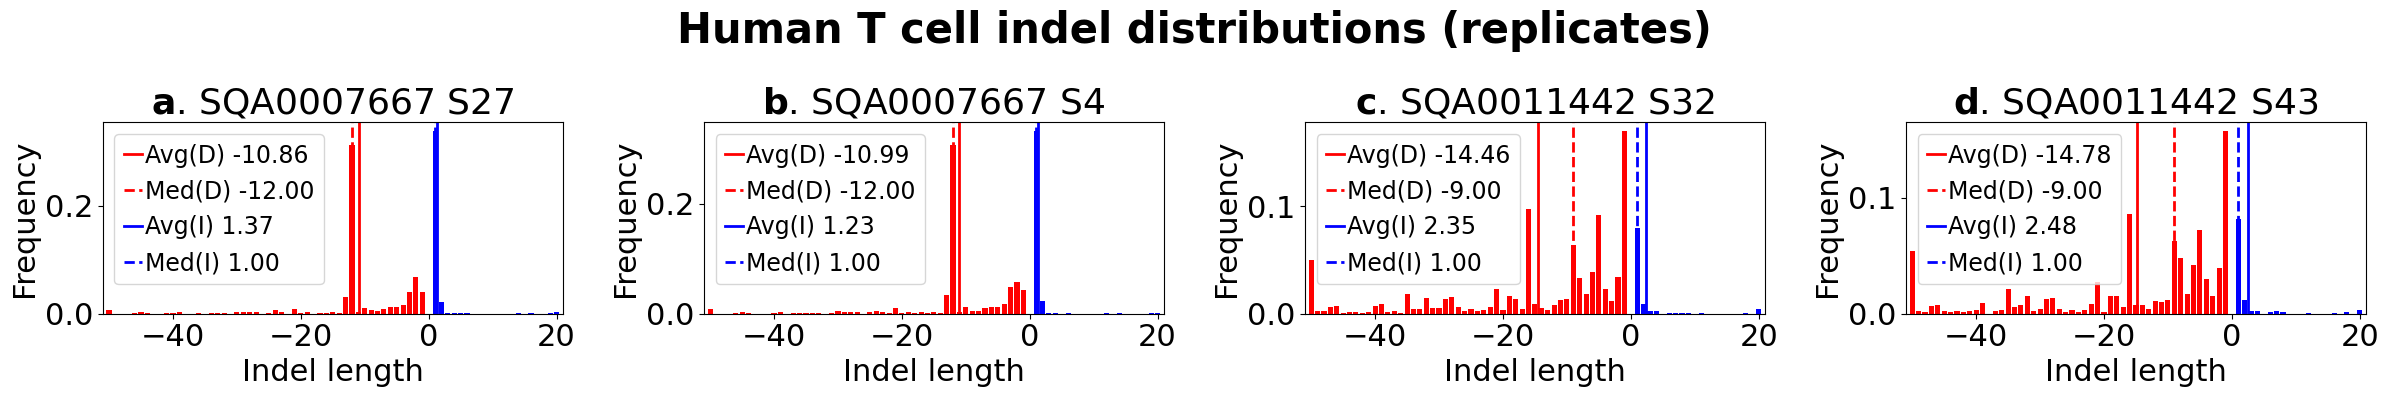

In [649]:
# plot_all_cells_new('',all_results, -50, 20, 'Tomato leaf editing products indel frequencies', '/tamir2/shaicohen1/CRISPR_MAAGAD/For_Eran',3)
plot_all_cells_new('',all_results, -50, 20, 'Human T cell indel distributions (replicates)', '/tamir2/shaicohen1/CRISPR_MAAGAD/For_Eran',2)
# plot_all_cells_new('all',all_results, -50, 20, 'Indel distributions', '/tamir2/shaicohen1/CRISPR_MAAGAD/For_Eran',3)
# plot_all_cells_new('',raw_tmh_results, -50, 20, '', '/tamir2/shaicohen1/CRISPR_MAAGAD/For_Eran/RAW_TMH_indels.svg',2,True)

In [594]:
all_results.keys()

dict_keys(['Fly', 'K562', 'T', 'U937', 'Prawn', 'PLX', 'Tomato leaf', 'Human', 'Tomato hairy roots', 'Tomato hairy roots (pseudo-short reads)', 'Tomato*'])

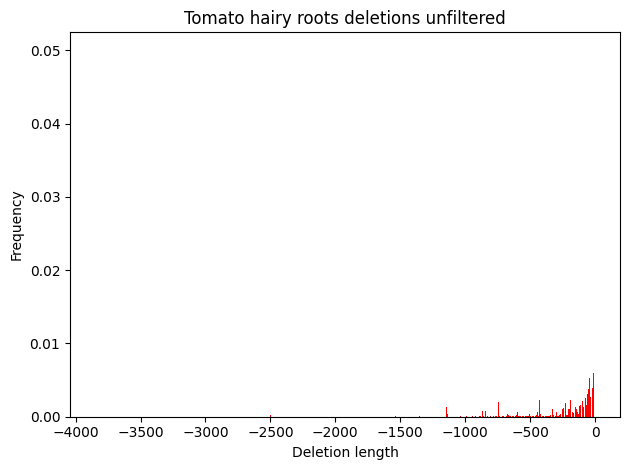

In [283]:
keys = [int(k) for k in tmh.keys()]
values = [float(v) for v in tmh.values()]

# keys = [int(k) for k in ALL_INS_lens.keys()]
# values = [float(v) for v in ALL_INS_lens.values()]
items = sorted((int(k), float(v)) for k, v in tmh.items())
keys_sorted = [k for k, v in items]
values_sorted = [v for k, v in items]

plt.figure()
plt.bar(keys, values,color='red')
neg_mean = np.average(lengths[neg_mask], weights=weights[neg_mask])
neg_median = weighted_median(lengths[neg_mask], weights[weights > 0][neg_mask])
ax.axvline(neg_mean, color="red", linestyle="-", linewidth=2)
ax.axvline(neg_median, color="red", linestyle="--", linewidth=2)
plt.xlabel("Deletion length")
plt.ylabel("Frequency")
plt.title("Tomato hairy roots deletions unfiltered")
plt.tight_layout()
plt.show()

In [241]:
cell_names = ['Human', 'Fly', 'Prawn', 'Tomato (pseudo-short reads)',
                      'K562', 'T', 'U937', 'PLX', 
                      'Tomato leaf', 'Tomato hairy roots']

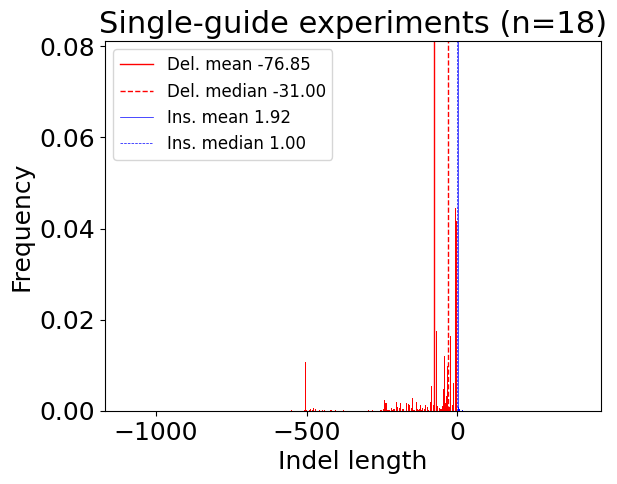

<Figure size 640x480 with 0 Axes>

In [312]:
# raw_tmh_results['Single-guide experiments (n=18)'] = SG_tmh.copy()
# raw_tmh_results['Unfiltered experiment (n=104)'] = tmh.copy()
ax = plt.subplot(rows, cols, i)
title='Single-guide experiments (n=18)'
freqs = raw_tmh_results[title]
# --- Split negative and positive keys ---
neg_keys  = [k for k in freqs.keys() if k < 0]
pos_keys  = [k for k in freqs.keys() if k > 0]

neg_vals = [freqs[k] for k in neg_keys]
pos_vals = [freqs[k] for k in pos_keys]

# --- Bars with colors ---
plt.bar(neg_keys, neg_vals, color="red")
plt.bar(pos_keys, pos_vals, color="blue")

# ---- Mean & Median (separately for neg & pos) ----
if neg_keys:
    neg_mean = np.average(neg_keys, weights=neg_vals)
    neg_median = weighted_median(neg_keys, neg_vals)
    plt.axvline(neg_mean, color="red", linestyle="-", linewidth=1,label=f"Del. mean {neg_mean:.2f}")
    plt.axvline(neg_median, color="red", linestyle="--", linewidth=1,label=f"Del. median {neg_median:.2f}")

if pos_keys:
    pos_mean = np.average(pos_keys, weights=pos_vals)
    pos_median = weighted_median(pos_keys, pos_vals)
    plt.axvline(pos_mean, color="blue", linestyle="-", linewidth=0.5,label=f"Ins. mean {pos_mean:.2f}")
    plt.axvline(pos_median, color="blue", linestyle="--", linewidth=0.5,label=f"Ins. median {pos_median:.2f}")

plt.title(title, fontsize=22)
plt.xlabel("Indel length", fontsize=18)
plt.ylabel("Frequency", fontsize=18)
plt.tick_params(labelsize=18)
plt.legend(fontsize=12)
# plt.tight_layout(rect=[0, 0, 1, 0.97])

outfile = f"/tamir2/shaicohen1/CRISPR_MAAGAD/For_Eran/Tomato hairy roots results/{title}.svg"
plt.show()
plt.savefig(outfile)

In [548]:
import statsmodels.stats.multitest as smm
p_values=[]
super_folder = Path('/tamir2/shaicohen1/CRISPR_MAAGAD/For_Eran')
folders_in_superfolder = [f for f in super_folder.iterdir() if f.is_dir()
and 'ipynb' not in str(f) and 'SORTED' not in str(f) and 'replicates' not in str(f) and 'mistake' not in str(f)]
binom_kn = {}
for folder in folders_in_superfolder:
    cell_name = str(folder).split('/')[-1]
    print(cell_name)
    freq_tables = list(folder.rglob("Alleles_frequency_table_around*"))
    if len(freq_tables) == 0:
        print(f"[WARNING] No CRISPResso allele tables found in: {folder}")
        continue
    k_obs,n = NEW_make_single_distribution(
        folder.name,
        freq_tables,
        -50,#args.min,
        20,#args.max,
        True, #args.indels,
        True,#args.nr
    )
    binom_kn[cell_name] = [k_obs,n]
    p_val = binom.sf(k_obs - 1, n, 0.5)   # P(K >= k_obs)
    p_values.append(p_val)
# plot_all_cells(curr_cell_results, args.min, args.max, args.title)
print('done')
reject, pvals_corrected, _, _ = smm.multipletests(
        p_values, 
        alpha=0.05,  # The desired FDR level (e.g., 0.05)
        method='fdr_bh'
    )
p_vals_df = pd.DataFrame({str(x): [p] for x,p in zip(cell_names,pvals_corrected)})
p_vals_df.index = ['#deletions > #insertions']
p_vals_df                        

Fly
K562
T
U937
Prawn
PLX
Tomato protoplasts
Human
Tomato hairy roots results
[WARNING] No CRISPResso allele tables found in: /tamir2/shaicohen1/CRISPR_MAAGAD/For_Eran/Tomato hairy roots results
done


,Human,Fly,Prawn,Tomato (pseudo-short reads),K562,T,U937,PLX
#deletions > #insertions,3.334260e-12,5.227288e-19,0.355697,0.000015,1.0,7.476117e-12,1.0,2.827583e-25


In [551]:
all_results.keys()

dict_keys(['Fly', 'K562', 'T', 'U937', 'Prawn', 'PLX', 'Tomato leaf', 'Human', 'Tomato hairy roots', 'Tomato hairy roots (pseudo-short reads)', 'Tomato*'])

In [555]:
# #deletions > #insertions - pooled approach (not per site!)
import statsmodels.stats.multitest as smm
p_values=[]
cell_names = ['Fly', 'K562', 'T', 'U937', 'Prawn', 'PLX', 'Tomato leaf', 'Human', 'Tomato hairy roots']
for name in cell_names:
    n = 10000 # a very lenient assumpution
    freq_del = sum([all_results[name][x] for x in all_results[name].keys() if x<0])
    k_obs = round(freq_del*n)
    p0 = 0.5
    
    
    # one-sided test
    p_val = binom.sf(k_obs - 1, n, p0)   # P(K >= k_obs)
    if p_val == 0: p_val = 4.041598016681946e-260
    p_values.append(p_val)
    # print(name, p_value)
reject, pvals_corrected, _, _ = smm.multipletests(
        p_values, 
        alpha=0.05,  # The desired FDR level (e.g., 0.05)
        method='fdr_bh'
    )
p_vals_df = pd.DataFrame({str(x): [p] for x,p in zip(cell_names,pvals_corrected)})
p_vals_df.index = ['#deletions > #insertions']
p_vals_df                        

,Fly,K562,T,U937,Prawn,PLX,Tomato leaf,Human,Tomato hairy roots
#deletions > #insertions,4.041598e-260,4.041598e-260,4.041598e-260,4.041598e-260,4.041598e-260,4.041598e-260,4.041598e-260,4.041598e-260,4.041598e-260


In [120]:
#shorter deletions are more common than longer - ks-test - not good
curr_cell_del_data = all_results['T']
num_events = curr_cell_del_data['sum_count']
curr_dels = {x:curr_cell_del_data['freqs'][x] for x in curr_cell_del_data['freqs'].keys() if x<0}
freqs = [round(num_events*x) for x in list(curr_dels.values())]
lengths = list(curr_dels.keys())

lengths = np.array([-1*x for x in lengths], dtype=int)   # fill with deletion lengths
freqs   = np.array(freqs, dtype=int ) # fill with their frequencies
# Expand into raw data for KS test:
data = np.repeat(lengths, freqs)

# Fit geometric distribution (support = {1,2,3,...})
# MLE for geometric parameter p:
mean_obs = np.mean(data)
p_hat = 1.0 / mean_obs

print("Estimated p (MLE):", p_hat)

# Build the geometric CDF to feed the KS test.
# SciPy's geom uses support {1,2,3,...} and pmf: p(1-p)^{k-1}


# Perform one-sample KS test:
D, p_value = kstest(data, geom(p_hat).cdf)

print("KS statistic D:", D)
print("p-value:", p_value)


Estimated p (MLE): 0.06621641249092229
KS statistic D: 0.11378113684267019
p-value: 2.770897440148871e-103


In [570]:
raw_tmh_results.keys()

dict_keys(['Single-guide experiments', 'Unfiltered experiments', 'Single-guide experiments (-50,20) ', 'Unfiltered experiments (-50,20) '])

In [572]:
#shorter deletions are more common than longer - spearman - good
p_values=[]
rs = []
for name in ['Single-guide experiments', 'Unfiltered experiments']:
    curr_cell_del_data = raw_tmh_results[name]
    curr_dels = {x:curr_cell_del_data[x] for x in curr_cell_del_data.keys() if x<0}
    freqs = list(curr_dels.values())
    lengths = list(curr_dels.keys())
    
    lengths = np.array([-1*x for x in lengths], dtype=int)   # fill with deletion lengths
    freqs   = np.array(freqs, dtype=float ) # fill with their frequencies
    r,p = spearmanr(lengths,freqs)
    # print(f'r {r:.2f} p {p}')
    p_values.append(p)
    rs.append(r)

reject, pvals_corrected, _, _ = smm.multipletests(
        p_values, 
        alpha=0.05,  # The desired FDR level (e.g., 0.05)
        method='fdr_bh'
    )
a = pd.DataFrame({str(x): [f'r= {r:.2f}, p= {p:.1e}'] for x,r,p in zip( ['Single-guide experiments', 'Unfiltered experiments'],rs,pvals_corrected)})
a.index = ['Length of deletions negatively correlates to frequency']
a

,Single-guide experiments,Unfiltered experiments
Length of deletions negatively correlates to frequency,"r= -0.74, p= 8.3e-97","r= -0.84, p= 0.0e+00"


In [561]:
#shorter deletions are more common than longer - spearman - good
p_values=[]
rs = []
for name in cell_names:
    curr_cell_del_data = all_results[name]
    curr_dels = {x:curr_cell_del_data[x] for x in curr_cell_del_data.keys() if x<0}
    freqs = list(curr_dels.values())
    lengths = list(curr_dels.keys())
    
    lengths = np.array([-1*x for x in lengths], dtype=int)   # fill with deletion lengths
    freqs   = np.array(freqs, dtype=float ) # fill with their frequencies
    r,p = spearmanr(lengths,freqs)
    # print(f'r {r:.2f} p {p}')
    p_values.append(p)
    rs.append(r)

reject, pvals_corrected, _, _ = smm.multipletests(
        p_values, 
        alpha=0.05,  # The desired FDR level (e.g., 0.05)
        method='fdr_bh'
    )
spearman_short_v_long_df = pd.DataFrame({str(x): [f'r= {r:.2f}, p= {p:.1e}'] for x,r,p in zip(cell_names,rs,pvals_corrected)})
spearman_short_v_long_df.index = ['Length of deletions negatively correlates to frequency']
spearman_short_v_long_df

,Fly,K562,T,U937,Prawn,PLX,Tomato leaf,Human,Tomato hairy roots
Length of deletions negatively correlates to frequency,"r= -0.97, p= 4.7e-72","r= -0.81, p= 2.9e-38","r= -0.98, p= 1.1e-90","r= -0.90, p= 1.4e-51","r= -0.77, p= 2.0e-24","r= -0.91, p= 3.2e-47","r= -0.61, p= 2.5e-12","r= -0.95, p= 9.0e-80","r= -0.86, p= 1.4e-164"


In [563]:
# #1-bp insertions > #all ~1-bp insertions combined - pooled approach (not per site!)
import statsmodels.stats.multitest as smm
p_values=[]
for name in cell_names:
    n_total = 10000
    # m = sum([1 for x in all_results[name]['freqs'].keys() if (x>0 and x!=1)])
    # print('m is', m)
    ins_size = 1
    all_non_1_freq_ins = sum([all_results[name][x] for x in all_results[name].keys() if (x>0 and x!=ins_size)])
    all_1_freq_ins = sum([all_results[name][x] for x in all_results[name].keys() if x==ins_size])
    k_obs = round(all_1_freq_ins*n_total)
    n = round((all_1_freq_ins+all_non_1_freq_ins)*n_total)
    p0 = 0.5   
    # one-sided test
    p_val = binom.sf(k_obs - 1, n, p0)   # P(K >= k_obs)
    if p_val == 0: p_val = 4.041598016681946e-260
    p_values.append(p_val)
    # print(name, p_value)
reject, pvals_corrected, _, _ = smm.multipletests(
        p_values, 
        alpha=0.05,  # The desired FDR level (e.g., 0.05)
        method='fdr_bh'
    )
ins_1_p_vals_df = pd.DataFrame({str(x): [p] for x,p in zip(cell_names,pvals_corrected)})
ins_1_p_vals_df.index = ['#1-bp insertions > all #~1-bp insertions']
ins_1_p_vals_df                        

,Fly,K562,T,U937,Prawn,PLX,Tomato leaf,Human,Tomato hairy roots
#1-bp insertions > all #~1-bp insertions,1.0,1.785259e-89,4.514720e-122,1.262798e-09,3.306614e-43,3.465351e-310,1.818719e-259,2.233458e-118,1.936535e-75


In [564]:
# #1-bp insertions > # ~1-bp insertions individually - pooled approach (not per site!)
import statsmodels.stats.multitest as smm
max_p_values=[]
for name in cell_names:
    p_values = []
    n_total = 10000
    ins_size = 1
    k = round(all_results[name][1]*n_total)
    for x in [x for x in all_results[name].keys() if x>1]:
        non_1 = round(all_results[name][x]*n_total)
        n = non_1+k
        p0 = 0.5   
        # one-sided test
        p_val = binom.sf(k - 1, n, p0)   # P(K >= k)
        if p_val == 0: p_val = 4.041598016681946e-260
        p_values.append(p_val)
    reject, max_pvals_corrected, _, _ = smm.multipletests(
            p_values, 
            alpha=0.05,  # The desired FDR level (e.g., 0.05)
            method='fdr_bh'
        )
    max_p_values.append(max(p_values))

    # print(name, p_value)
reject, pvals_corrected, _, _ = smm.multipletests(
        max_p_values, 
        alpha=0.05,  # The desired FDR level (e.g., 0.05)
        method='fdr_bh'
    )
ins_1_ind_p_vals_df = pd.DataFrame({str(x): [p] for x,p in zip(cell_names,pvals_corrected)})
ins_1_ind_p_vals_df.index = ['#1-bp insertions > #~1-bp insertions individually']
ins_1_ind_p_vals_df                        

,Fly,K562,T,U937,Prawn,PLX,Tomato leaf,Human,Tomato hairy roots
#1-bp insertions > #~1-bp insertions individually,3.157611e-09,2.521861e-230,6.106216e-190,4.731317e-82,1.574731e-69,1.818719e-259,1.818719e-259,1.473428e-225,1.815818e-122


In [565]:
table_s14 = pd.concat([p_vals_df.astype(str), spearman_short_v_long_df.astype(str), ins_1_ind_p_vals_df.astype(str)])

In [568]:
table_s14

,Fly,K562,T,U937,Prawn,PLX,Tomato leaf,Human,Tomato hairy roots
#deletions > #insertions,4e-260,4e-260,4e-260,4e-260,4e-260,4e-260,4e-260,4e-260,4e-260
Length of deletions negatively correlates to frequency,"r= -0.97, p= 4.7e-72","r= -0.81, p= 2.9e-38","r= -0.98, p= 1.1e-90","r= -0.90, p= 1.4e-51","r= -0.77, p= 2.0e-24","r= -0.91, p= 3.2e-47","r= -0.61, p= 2.5e-12","r= -0.95, p= 9.0e-80","r= -0.86, p= 1.4e-164"
#1-bp insertions > #~1-bp insertions individually,3.157611373077901e-09,2.521860969437437e-230,6.10621550271653e-190,4.731316845508489e-82,1.5747305546064625e-69,1.818719107506876e-259,1.818719107506876e-259,1.4734284812106543e-225,1.8158184468635254e-122


In [567]:
table_s14.iloc[0,:] = [x[0] + x[-5:] for x in table_s14.iloc[0,:]]

In [238]:
[x[0] + x[-4:] for x in table_s14.iloc[0,:]]

['4-260', '4-260', '4-260', '4-260', '4-260', '4-260', '4-260', '4-260']

In [242]:
table_s14.iloc[2,:] = [x[0] + x[x.find('e'):] for x in table_s14.iloc[2,:]]

In [586]:
table_s14.to_excel('Table_S13.xlsx')

In [582]:
a=[]
for x,y in zip(table_s14.columns,table_s14.loc['Length of deletions negatively correlates to frequency']):
    a.append(f'{x} {y}')
print('; '.join(a))

Fly r= -0.97, p= 4.7e-72; K562 r= -0.81, p= 2.9e-38; T r= -0.98, p= 1.1e-90; U937 r= -0.90, p= 1.4e-51; Prawn r= -0.77, p= 2.0e-24; PLX r= -0.91, p= 3.2e-47; Tomato leaf r= -0.61, p= 2.5e-12; Human r= -0.95, p= 9.0e-80; Tomato hairy roots r= -0.86, p= 1.4e-164


In [584]:
table_s14.iloc[2,:] = [x[0] + x[x.find('e'):] for x in table_s14.iloc[2,:]]

In [589]:
table_s14

,Fly,K562,T,U937,Prawn,PLX,Tomato leaf,Human,Tomato hairy roots
#deletions > #insertions,4e-260,4e-260,4e-260,4e-260,4e-260,4e-260,4e-260,4e-260,4e-260
Length of deletions negatively correlates to frequency,"r= -0.97, p= 4.7e-72","r= -0.81, p= 2.9e-38","r= -0.98, p= 1.1e-90","r= -0.90, p= 1.4e-51","r= -0.77, p= 2.0e-24","r= -0.91, p= 3.2e-47","r= -0.61, p= 2.5e-12","r= -0.95, p= 9.0e-80","r= -0.86, p= 1.4e-164"
#1-bp insertions > #~1-bp insertions individually,3e-09,2e-230,6e-190,4e-82,1e-69,1e-259,1e-259,1e-225,1e-122


In [592]:
a=[]
for x,y in zip(table_s14.columns,table_s14.loc['#1-bp insertions > #~1-bp insertions individually']):
    a.append(f'{x} p={y}')
print('; '.join(a))

Fly p=3e-09; K562 p=2e-230; T p=6e-190; U937 p=4e-82; Prawn p=1e-69; PLX p=1e-259; Tomato leaf p=1e-259; Human p=1e-225; Tomato hairy roots p=1e-122
